In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [3]:
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.optimizers import Adam

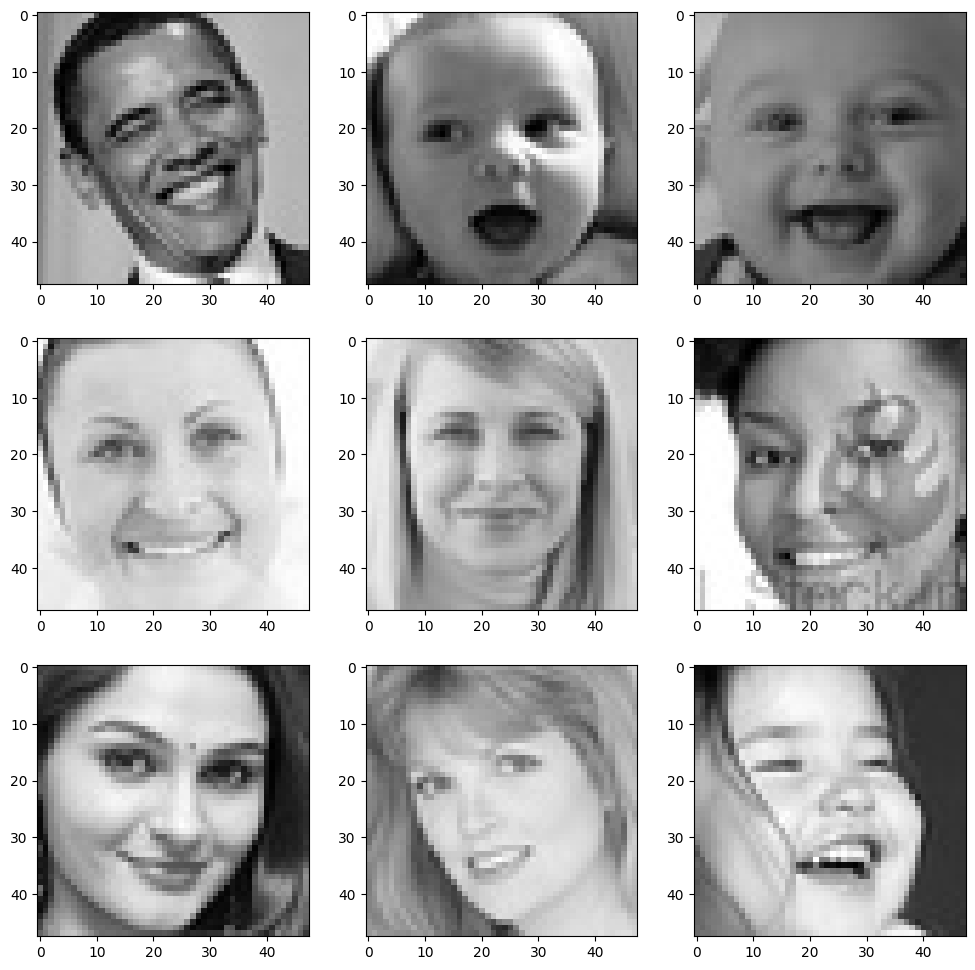

In [4]:
picture_size = 48
folder_path = "dataset/"
expression = 'happy'

plt.figure(figsize=(12,12))

for i in range(1,10,1):

    plt.subplot(3,3,i)

    img = load_img(
        folder_path+"train/"+expression+"/"+
        os.listdir(folder_path+"train/"+expression)[i],
        target_size=(picture_size,picture_size)
    )

    plt.imshow(img)

plt.show()

In [5]:
batch_size = 128

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
train_set = train_datagen.flow_from_directory(
    folder_path+"train",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

Found 28821 images belonging to 7 classes.


In [7]:
test_set = validation_datagen.flow_from_directory(
    folder_path+"validation",
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 7066 images belonging to 7 classes.


In [8]:
no_of_classes = 7

model = Sequential()

In [9]:
model.add(
    Conv2D(
        64,
        (3,3),
        padding='same',
        input_shape=(48,48,1)
    )
)

model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.add(
    Conv2D(
        128,
        (5,5),
        padding='same'
    )
)

model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

In [11]:
model.add(
    Conv2D(
        512,
        (3,3),
        padding='same'
    )
)

model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

In [12]:
model.add(
    Conv2D(
        512,
        (3,3),
        padding='same'
    )
)

model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Dropout(0.25))

In [13]:
model.add(Flatten())

In [14]:
model.add(Dense(256))

model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dropout(0.25))

In [15]:
model.add(Dense(no_of_classes, activation='softmax'))

In [16]:
opt = Adam(learning_rate=0.0001)

model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,02

 Total params: 4,343,303 (16.57 MB)

 Trainable params: 4,340,359 (16.56 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [21]:
history = model.fit(
    train_set,
    epochs=30,
    validation_data=test_set
)

Epoch 1/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.2783 - loss: 1.8373 - val_accuracy: 0.2934 - val_loss: 1.8315
Epoch 2/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - accuracy: 0.3062 - loss: 1.7705 - val_accuracy: 0.3439 - val_loss: 1.6916
Epoch 3/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.3316 - loss: 1.7195 - val_accuracy: 0.3849 - val_loss: 1.5939
Epoch 4/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 501s 2s/step - accuracy: 0.3559 - loss: 1.6706 - val_accuracy: 0.4059 - val_loss: 1.5177
Epoch 5/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.3715 - loss: 1.6285 - val_accuracy: 0.4304 - val_loss: 1.4799
Epoch 6/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 502s 2s/step - accuracy: 0.3913 - loss: 1.5824 - val_accuracy: 0.4308 - val_loss: 1.4871
Epoch 7/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.4085 - loss: 1.5447 - val_accuracy: 0.4543 - val_loss: 1.4535
Epoch 8/30
226/226 ━━━━━━━━━━━━━━━━━━━━ 496s 2s/step - accuracy: 0.4238 - loss: 1.5078 - val_accu

KeyboardInterrupt: 

In [ ]:
model.save("model.h5")

NameError: name 'history' is not defined

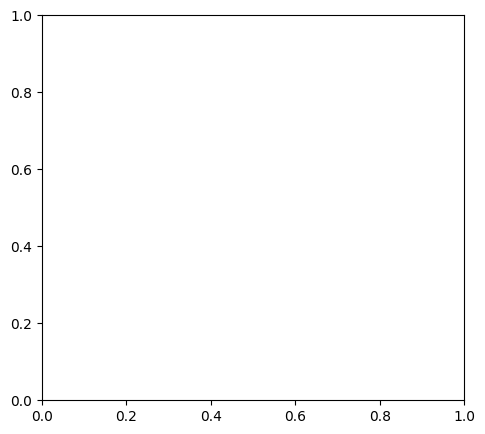

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

In [23]:
model.save("model.h5")

NameError: name 'history' is not defined

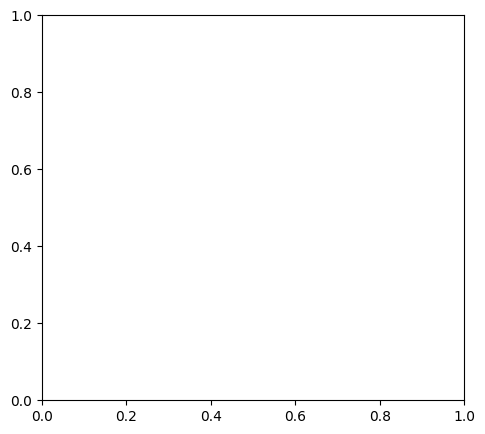

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

NameError: name 'history' is not defined

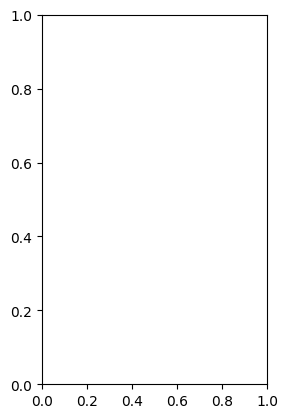

In [25]:
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()